In [1]:
import cv2
import matplotlib.pyplot as plt
import importlib
import preprocessing
importlib.reload(preprocessing)  # pick up any edits without restarting kernel

FloorPlanPreprocessor = preprocessing.FloorPlanPreprocessor

# IMG_PATH = "data/PNG/raw/IIa_A01001.png"

# image = cv2.imread(IMG_PATH)
# if image is None:
#     raise FileNotFoundError(IMG_PATH)

# print(f"Loaded: {IMG_PATH}  shape={image.shape}")

In [2]:
# preprocessor = FloorPlanPreprocessor(angle_step=90)
# result = preprocessor.process(image)

# plt.subplot(1, 2, 1)
# plt.imshow(cv2.cvtColor(result.raw_no_text, cv2.COLOR_BGR2RGB))
# plt.title("raw_no_text")
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(cv2.cvtColor(result.preprocessed, cv2.COLOR_BGR2RGB))
# plt.title("ocr_pad")
# plt.axis("off")
# plt.show()

libpng warning: iCCP: known incorrect sRGB profile
/opt/homebrew/Caskroom/miniconda/base/envs/floor-plan/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


rotation_angle : 90°
crop_bbox      : (56, 472, 2433, 2656)
corners        : 95
walls          : 67
doors          : 11
windows        : 4
graph          : 110 nodes, 87 edges

{
  "walls": [
    {
      "id": "wall_1",
      "start": {
        "x": 1441,
        "y": 1950
      },
      "end": {
        "x": 975,
        "y": 1948
      }
    },
    {
      "id": "wall_2",
      "start": {
        "x": 1640,
        "y": 1532
      },
      "end": {
        "x": 1640,
        "y": 1211
      }
    },
    {
      "id": "wall_3",
      "start": {
        "x": 603,
        "y": 951
      },
      "end": {
        "x": 825,
        "y": 951
      }
    },
    {
      "id": "wall_4",
      "start": {
        "x": 1192,
        "y": 961
      },
      "end": {
        "x": 2147,
        "y": 1024
      }
    },
    {
      "id": "wall_5",
      "start": {
        "x": 2147,
        "y": 1024
      },
      "end": {
        "x": 2159,
        "y": 604
      }
    },
    {
      "id": "wall_6

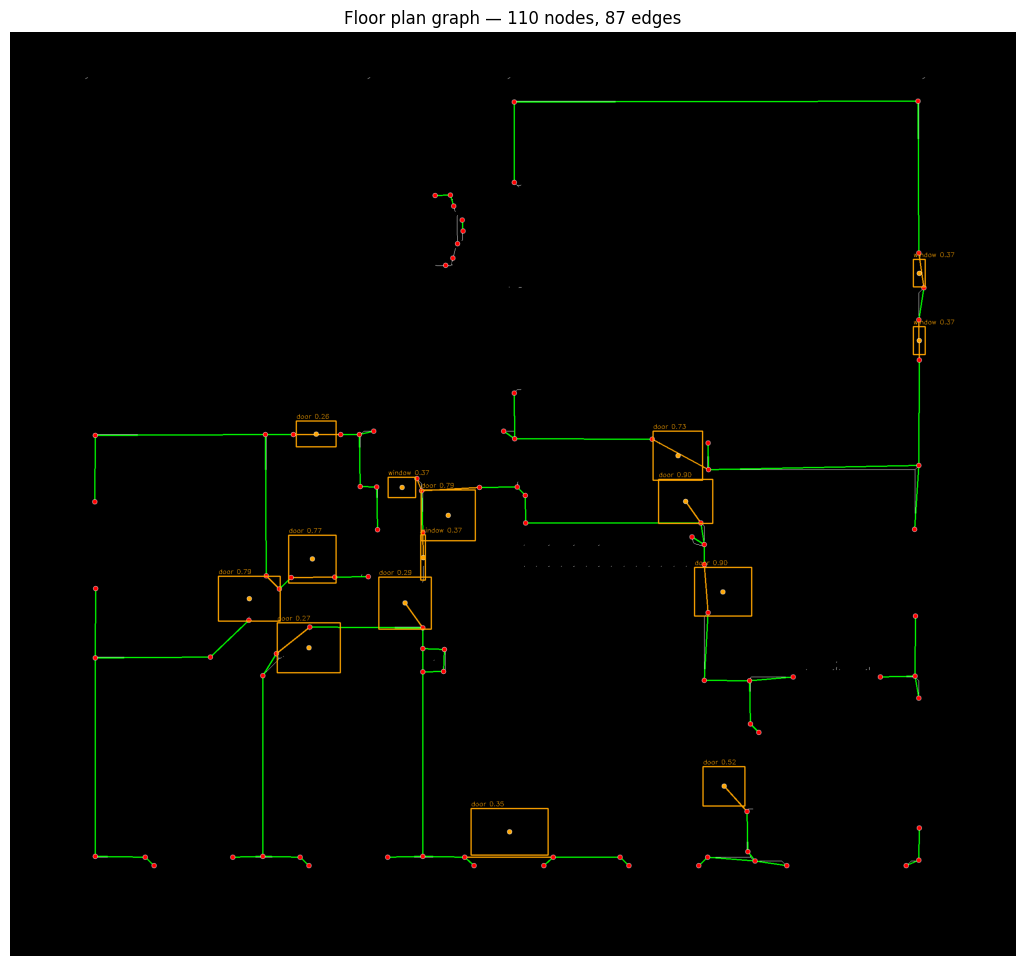

In [3]:
import importlib
import pipeline as pl
importlib.reload(pl)

import json
import networkx as nx

img_path = "data/PNG/raw/IIa_BA0710.png"
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(img_path)

out = pl.run_pipeline(image)

prep = out.prep
skel = out.skel
G    = out.graph

n_doors   = sum(1 for o in out.json["openings"] if o["type"] == "door")
n_windows = sum(1 for o in out.json["openings"] if o["type"] == "window")

print(f"rotation_angle : {prep.rotation_angle}°")
print(f"crop_bbox      : {prep.crop_bbox}")
print(f"corners        : {len(skel.corners)}")
print(f"walls          : {len(out.json['walls'])}")
print(f"doors          : {n_doors}")
print(f"windows        : {n_windows}")
print(f"graph          : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print()
print(json.dumps(out.json, indent=2))

# Overlay: skeleton + wall edges (green) + opening edges (orange) + bboxes
vis = cv2.cvtColor(skel.skeleton_raw, cv2.COLOR_GRAY2BGR)
COLORS = {"wall": (0, 255, 0), "opening": (0, 165, 255)}
for a, b, edata in G.edges(data=True):
    pa = (int(G.nodes[a]["x"]), int(G.nodes[a]["y"]))
    pb = (int(G.nodes[b]["x"]), int(G.nodes[b]["y"]))
    cv2.line(vis, pa, pb, COLORS.get(edata["kind"], (200, 200, 200)), 2)
for n, attr in G.nodes(data=True):
    p = (int(attr["x"]), int(attr["y"]))
    color = (0, 0, 255) if attr["kind"] == "corner" else (0, 165, 255)
    cv2.circle(vis, p, 6, color, -1)
    cv2.circle(vis, p, 6, (255, 255, 255), 1)
    if "bbox" in attr:
        x1, y1, x2, y2 = (int(v) for v in attr["bbox"])
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 165, 255), 2)
        cv2.putText(vis, f"{attr['kind']} {attr['conf']:.2f}",
                    (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)

plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Floor plan graph — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

In [4]:
import glob
import json
import importlib
from pathlib import Path

import cv2
import pipeline as pl
importlib.reload(pl)

RAW_DIR      = Path("data/PNG/raw")
NO_TEXT_DIR  = Path("data/PNG/no_text")
CROP_DIR     = Path("data/PNG/crop_and_pad")
GRAPH_DIR    = Path("data/PNG/graph")
JSON_DIR     = Path("data/PNG/json")

for d in (NO_TEXT_DIR, CROP_DIR, GRAPH_DIR, JSON_DIR):
    d.mkdir(parents=True, exist_ok=True)

images = sorted(RAW_DIR.glob("*.png"))
print(f"Found {len(images)} images\n")

preprocessor = pl.FloorPlanPreprocessor(angle_step=90)
model        = pl.YOLO("Models/best_v2.pt")

for i, img_path in enumerate(images, 1):
    stem  = img_path.stem
    image = cv2.imread(str(img_path))
    if image is None:
        print(f"[{i:3}/{len(images)}] SKIP  {stem}  (could not load)")
        continue

    try:
        out = pl.run_pipeline(image, preprocessor=preprocessor)
    except Exception as exc:
        print(f"[{i:3}/{len(images)}] ERROR {stem}: {exc}")
        continue

    # ── save intermediate images ──────────────────────────────────────────────
    cv2.imwrite(str(NO_TEXT_DIR / f"{stem}.png"), out.prep.raw_no_text)
    cv2.imwrite(str(CROP_DIR    / f"{stem}.png"), out.prep.preprocessed)

    # ── skeleton overlay ──────────────────────────────────────────────────────
    G   = out.graph
    vis = cv2.cvtColor(out.skel.skeleton_raw, cv2.COLOR_GRAY2BGR)
    COLORS = {"wall": (0, 255, 0), "opening": (0, 165, 255)}
    for a, b, edata in G.edges(data=True):
        pa = (int(G.nodes[a]["x"]), int(G.nodes[a]["y"]))
        pb = (int(G.nodes[b]["x"]), int(G.nodes[b]["y"]))
        cv2.line(vis, pa, pb, COLORS.get(edata["kind"], (200, 200, 200)), 2)
    for n, attr in G.nodes(data=True):
        p     = (int(attr["x"]), int(attr["y"]))
        color = (0, 0, 255) if attr["kind"] == "corner" else (0, 165, 255)
        cv2.circle(vis, p, 6, color, -1)
        cv2.circle(vis, p, 6, (255, 255, 255), 1)
        if "bbox" in attr:
            x1, y1, x2, y2 = (int(v) for v in attr["bbox"])
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 165, 255), 2)
            cv2.putText(vis, f"{attr['kind']} {attr.get('conf', 0):.2f}",
                        (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 165, 255), 1)
    cv2.imwrite(str(GRAPH_DIR / f"{stem}_graph.png"), vis)

    # ── JSON ──────────────────────────────────────────────────────────────────
    with open(JSON_DIR / f"{stem}.json", "w") as f:
        json.dump(out.json, f, indent=2)

    n_doors   = sum(1 for o in out.json["openings"] if o["type"] == "door")
    n_windows = sum(1 for o in out.json["openings"] if o["type"] == "window")
    print(f"[{i:3}/{len(images)}] OK    {stem:30s}  "
          f"corners={len(out.skel.corners):4d}  walls={len(out.json['walls']):4d}  "
          f"doors={n_doors:3d}  windows={n_windows:3d}")

print("\nDone.")


Found 90 images



libpng warning: iCCP: known incorrect sRGB profile


[  1/90] OK    IIa_A01001                      corners=  70  walls=  46  doors=  9  windows=  4


libpng warning: iCCP: known incorrect sRGB profile


[  2/90] OK    IIa_AP3301                      corners=  92  walls=  74  doors= 15  windows=  8


...

[ 88/90] OK    Ic_MU0703_sommaire              corners=  75  walls=  63  doors=  5  windows=  8


libpng warning: iCCP: known incorrect sRGB profile


[ 89/90] OK    Ic_RD0602_sommaire              corners=  73  walls=  61  doors=  7  windows=  2


libpng warning: iCCP: known incorrect sRGB profile


[ 90/90] OK    Ic_RE0503_sommaire              corners=  47  walls=  34  doors=  6  windows=  4

Done.
